# Proyecto Final — Clasificador Multi-Clase

## Dataset elegido: Wine (sklearn)

**Clases:** 0, 1, 2 (tres variedades de vino)

# Importar librerías

In [1]:
!pip install tensorflow xgboost --quiet

In [2]:
# Librerías estándar
import random
import os
from collections import Counter
import datetime
from zoneinfo import ZoneInfo

# Visualización
import matplotlib.pyplot as plt
import numpy as np

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ML
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)
import xgboost as xgb
from scipy.stats import mode

# Cargar Dataset

## Justificación del dataset elegido

Se eligió el dataset **Wine** de scikit-learn por las siguientes razones:

- **Tamaño manejable:** Con solo 178 instancias y 13 features, permite iterar rápidamente sobre múltiples experimentos y familias de modelos sin un costo computacional elevado.
- **Calidad de los datos:** No presenta valores faltantes ni registros duplicados, por lo que no se requieren técnicas de imputación ni limpieza adicional.
- **Escalas razonables:** Aunque las features tienen rangos distintos (por ejemplo, `proline` vs `ash`), las diferencias no son extremas y el escalado estándar es suficiente para normalizar los datos antes de entrenar la red neuronal.
- **Problema multi-clase bien definido:** Cuenta con exactamente 3 clases balanceadas, lo cual es ideal para comparar modelos con métricas macro como F1, precision y recall sin que el desbalance de clases sea un factor de confusión.

In [3]:
dataset = load_wine(as_frame=True)
df = dataset.frame
feature_names = dataset.feature_names
print("Dataset cargado correctamente.")
print(f"Shape: {df.shape}")
print(f"Features: {list(feature_names)}")

Dataset cargado correctamente.
Shape: (178, 14)
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


# Exploración

In [4]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [6]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


# EDA

## Número de datos y features

In [7]:
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

Número de filas: 178
Número de columnas: 14


## Valores nulos (Missing values)

In [8]:
df.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


## Datos duplicados

In [9]:
print("Duplicados:", df.duplicated().sum())

Duplicados: 0


## Histogramas por feature

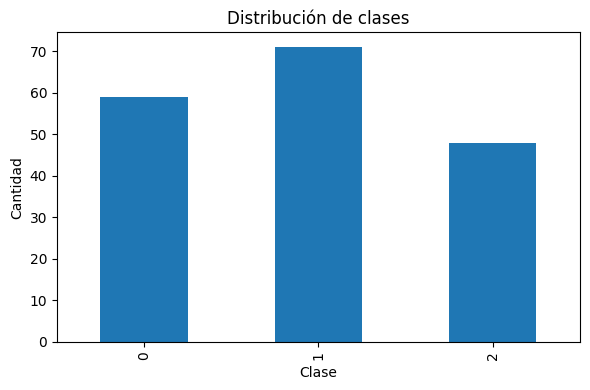

In [10]:
df["target"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6,4)
)
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

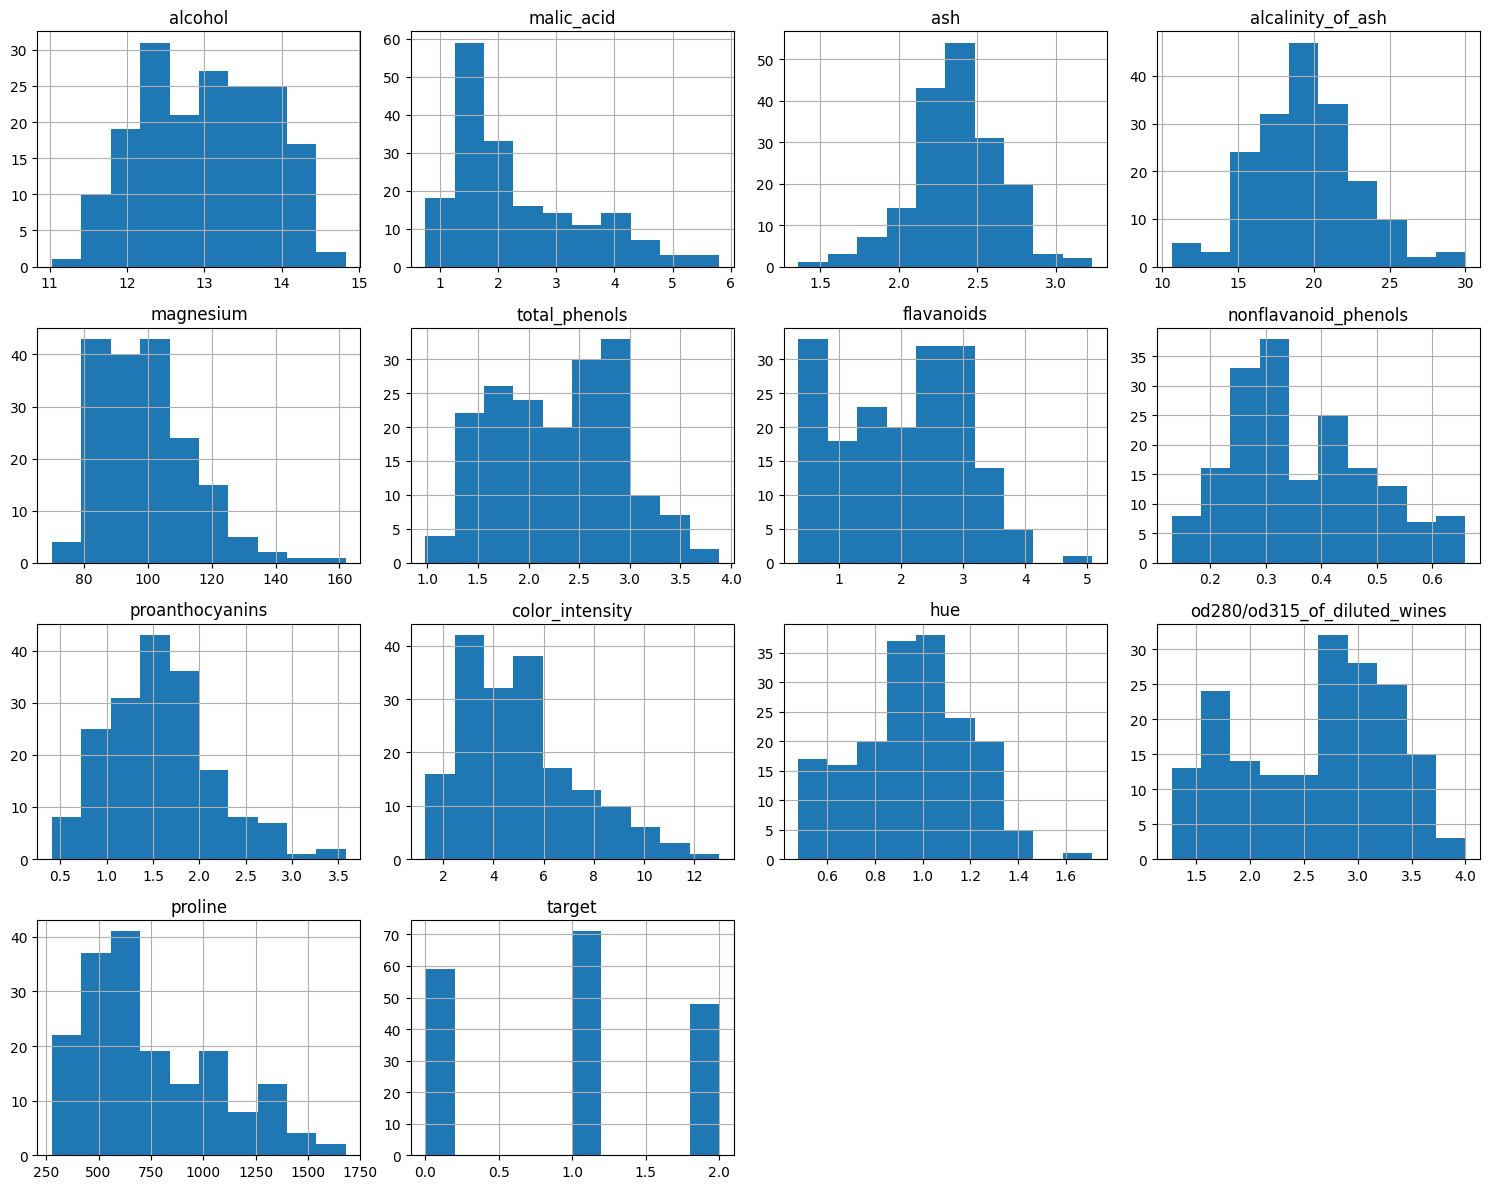

In [11]:
df.hist(figsize=(15,12))
plt.tight_layout()
plt.show()

## Análisis de correlación

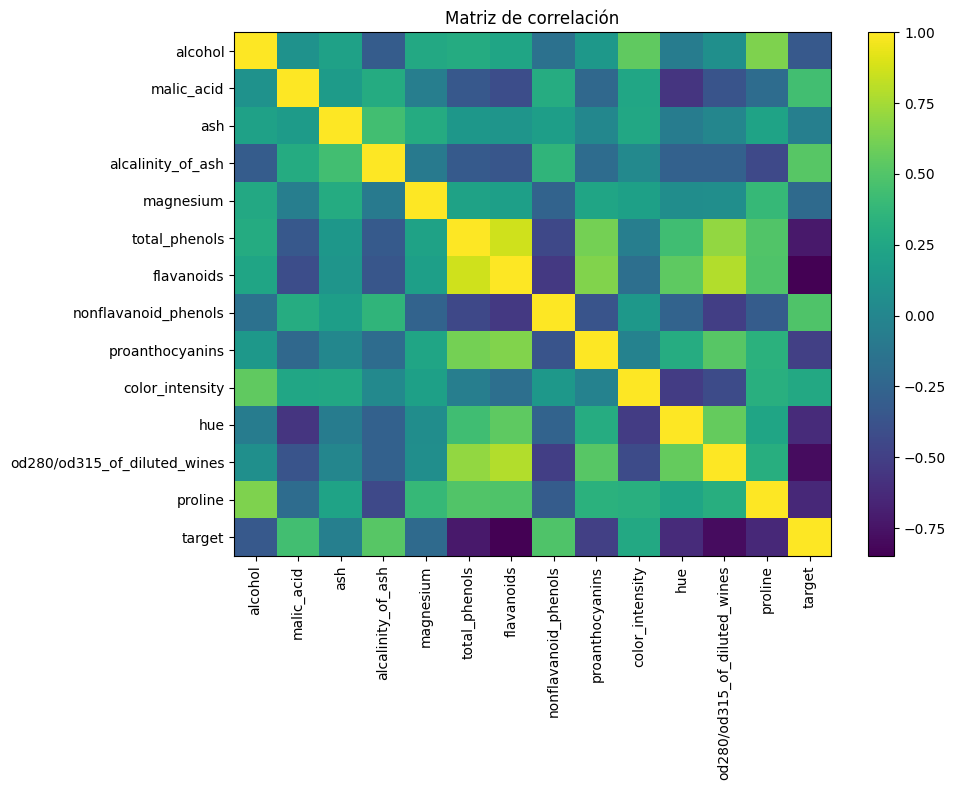

In [12]:
corr = df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

In [13]:
corr_target = df.corr()["target"].sort_values(ascending=False)
print(corr_target)

target                          1.000000
alcalinity_of_ash               0.517859
nonflavanoid_phenols            0.489109
malic_acid                      0.437776
color_intensity                 0.265668
ash                            -0.049643
magnesium                      -0.209179
alcohol                        -0.328222
proanthocyanins                -0.499130
hue                            -0.617369
proline                        -0.633717
total_phenols                  -0.719163
od280/od315_of_diluted_wines   -0.788230
flavanoids                     -0.847498
Name: target, dtype: float64


# Entrenamiento

## Split dataset Train y Test

> Train-test split 80/20

In [14]:
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Distribución train:", dict(Counter(y_train)))
print("Distribución test:", dict(Counter(y_test)))

Train: (142, 13)
Test: (36, 13)
Distribución train: {0: 47, 2: 38, 1: 57}
Distribución test: {0: 12, 2: 10, 1: 14}


## Escalado de datos

El escalado se aplica a los datos escalados para la Red Neuronal. Random Forest y XGBoost usan datos sin escalar (son invariantes a escala).

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## Bitácora de experimentos (CSV)

In [16]:
BITACORA = "bitacora_experimentos.csv"

def calcular_metricas(y_true, y_pred, sufijo):
    return {
        f"precision_{sufijo}": precision_score(y_true, y_pred, average="macro", zero_division=0),
        f"recall_{sufijo}":    recall_score(y_true, y_pred, average="macro", zero_division=0),
        f"f1_{sufijo}":        f1_score(y_true, y_pred, average="macro", zero_division=0),
        f"accuracy_{sufijo}":  accuracy_score(y_true, y_pred),
    }

def registrar_experimento(experimento_id, modelo, hiperparametros, arquitectura, model,
                           X_tr=None, X_te=None, y_tr=None, y_te=None, is_nn=False):
    if X_tr is None:
        X_tr = X_train_scaled if is_nn else X_train.values
    if X_te is None:
        X_te = X_test_scaled if is_nn else X_test.values
    if y_tr is None:
        y_tr = y_train
    if y_te is None:
        y_te = y_test

    fila = {
        "experimento_id": experimento_id,
        "timestamp": datetime.datetime.now(ZoneInfo("America/Guatemala")).strftime("%Y-%m-%d %H:%M:%S"),
        "modelo": modelo,
        "hiperparametros": str(hiperparametros),
        "arquitectura": arquitectura,
    }

    if is_nn:
        y_pred_train = np.argmax(model.predict(X_tr, verbose=0), axis=1)
        y_pred_test  = np.argmax(model.predict(X_te, verbose=0), axis=1)
    else:
        y_pred_train = model.predict(X_tr)
        y_pred_test  = model.predict(X_te)

    fila.update(calcular_metricas(y_tr, y_pred_train, "train"))
    fila.update(calcular_metricas(y_te,  y_pred_test,  "test"))

    pd.DataFrame([fila]).to_csv(
        BITACORA,
        mode="a",
        header=not os.path.exists(BITACORA),
        index=False
    )
    return fila

## Familia 1 — Random Forest

Se ejecutan **5 experimentos** variando `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features` y `criterion`.

In [17]:
configuraciones_rf = [
    {"n_estimators": 100,  "max_depth": 5},
    {"n_estimators": 200,  "max_depth": 10},
    {"n_estimators": 300,  "max_depth": None},
    {"n_estimators": 150,  "max_depth": 8,    "min_samples_leaf": 2},
    {"n_estimators": 400,  "max_depth": 15,   "max_features": "sqrt"},
]

resultados_rf = []
modelos_rf    = []

for i, cfg in enumerate(configuraciones_rf, start=1):
    print("="*50)
    print(f"Entrenando RF_{i:02d}")
    print(cfg)

    modelo = RandomForestClassifier(**cfg, random_state=42)
    modelo.fit(X_train, y_train)
    modelos_rf.append(modelo)

    fila = registrar_experimento(
        experimento_id=f"RF_{i:02d}",
        modelo="random_forest",
        hiperparametros=cfg,
        arquitectura="Random Forest",
        model=modelo,
    )
    resultados_rf.append(fila)
    print(f"  F1 train={fila['f1_train']:.4f}  |  F1 test={fila['f1_test']:.4f}")

Entrenando RF_01
{'n_estimators': 100, 'max_depth': 5}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


  F1 train=1.0000  |  F1 test=1.0000
Entrenando RF_02
{'n_estimators': 200, 'max_depth': 10}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


  F1 train=1.0000  |  F1 test=1.0000
Entrenando RF_03
{'n_estimators': 300, 'max_depth': None}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


  F1 train=1.0000  |  F1 test=1.0000
Entrenando RF_04
{'n_estimators': 150, 'max_depth': 8, 'min_samples_leaf': 2}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


  F1 train=1.0000  |  F1 test=1.0000
Entrenando RF_05
{'n_estimators': 400, 'max_depth': 15, 'max_features': 'sqrt'}
  F1 train=1.0000  |  F1 test=1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [18]:
df_rf = pd.DataFrame(resultados_rf)
display(df_rf[["experimento_id","hiperparametros","f1_train","f1_test"]])

,experimento_id,hiperparametros,f1_train,f1_test
0,RF_01,"{'n_estimators': 100, 'max_depth': 5}",1.0,1.0
1,RF_02,"{'n_estimators': 200, 'max_depth': 10}",1.0,1.0
2,RF_03,"{'n_estimators': 300, 'max_depth': None}",1.0,1.0
3,RF_04,"{'n_estimators': 150, 'max_depth': 8, 'min_sam...",1.0,1.0
4,RF_05,"{'n_estimators': 400, 'max_depth': 15, 'max_fe...",1.0,1.0


In [19]:
mejor_rf_row = df_rf.loc[df_rf["f1_test"].idxmax()]
mejor_rf_idx = df_rf["f1_test"].idxmax()
mejor_rf = modelos_rf[mejor_rf_idx]

print(f"Mejor RF: {mejor_rf_row['experimento_id']}")
print(f"  F1 train = {mejor_rf_row['f1_train']:.4f}")
print(f"  F1 test  = {mejor_rf_row['f1_test']:.4f}")
display(mejor_rf_row)

Mejor RF: RF_01
  F1 train = 1.0000
  F1 test  = 1.0000


,0
experimento_id,RF_01
timestamp,2026-06-30 22:10:57
modelo,random_forest
hiperparametros,"{'n_estimators': 100, 'max_depth': 5}"
arquitectura,Random Forest
precision_train,1.0
recall_train,1.0
f1_train,1.0
accuracy_train,1.0
precision_test,1.0


## Familia 2 — XGBoost

Se ejecutan **5 experimentos** variando `n_estimators`, `max_depth`, `learning_rate`, `subsample` y `colsample_bytree`.

In [20]:
configuraciones_xgb = [
    {"n_estimators": 100,  "max_depth": 1, "learning_rate": 0.1},
    {"n_estimators": 200,  "max_depth": 2, "learning_rate": 0.05},
    {"n_estimators": 300,  "max_depth": 3, "learning_rate": 0.01, "subsample": 0.8},
    {"n_estimators": 150,  "max_depth": 5, "learning_rate": 0.1,  "colsample_bytree": 0.8},
    {"n_estimators": 400,  "max_depth": 4, "learning_rate": 0.05, "reg_lambda": 1.5},
]

resultados_xgb = []
modelos_xgb    = []

for i, cfg in enumerate(configuraciones_xgb, start=1):
    print("="*50)
    print(f"Entrenando XGB_{i:02d}")
    print(cfg)

    modelo = xgb.XGBClassifier(
        **cfg,
        random_state=42,
        use_label_encoder=False,
        eval_metric="mlogloss",
        verbosity=0,
    )
    modelo.fit(X_train, y_train)
    modelos_xgb.append(modelo)

    fila = registrar_experimento(
        experimento_id=f"XGB_{i:02d}",
        modelo="xgboost",
        hiperparametros=cfg,
        arquitectura="XGBoost",
        model=modelo,
    )
    resultados_xgb.append(fila)
    print(f"  F1 train={fila['f1_train']:.4f}  |  F1 test={fila['f1_test']:.4f}")

Entrenando XGB_01
{'n_estimators': 100, 'max_depth': 1, 'learning_rate': 0.1}
  F1 train=1.0000  |  F1 test=0.9743
Entrenando XGB_02
{'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.05}
  F1 train=1.0000  |  F1 test=1.0000
Entrenando XGB_03
{'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.8}
  F1 train=1.0000  |  F1 test=0.9743
Entrenando XGB_04
{'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
  F1 train=1.0000  |  F1 test=1.0000
Entrenando XGB_05
{'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.05, 'reg_lambda': 1.5}
  F1 train=1.0000  |  F1 test=0.9743


In [21]:
df_xgb = pd.DataFrame(resultados_xgb)
display(df_xgb[["experimento_id","hiperparametros","f1_train","f1_test"]])

,experimento_id,hiperparametros,f1_train,f1_test
0,XGB_01,"{'n_estimators': 100, 'max_depth': 1, 'learnin...",1.0,0.974321
1,XGB_02,"{'n_estimators': 200, 'max_depth': 2, 'learnin...",1.0,1.000000
2,XGB_03,"{'n_estimators': 300, 'max_depth': 3, 'learnin...",1.0,0.974321
3,XGB_04,"{'n_estimators': 150, 'max_depth': 5, 'learnin...",1.0,1.000000
4,XGB_05,"{'n_estimators': 400, 'max_depth': 4, 'learnin...",1.0,0.974321


In [22]:
mejor_xgb_row = df_xgb.loc[df_xgb["f1_test"].idxmax()]
mejor_xgb_idx = df_xgb["f1_test"].idxmax()
mejor_xgb = modelos_xgb[mejor_xgb_idx]

print(f"Mejor XGB: {mejor_xgb_row['experimento_id']}")
print(f"  F1 train = {mejor_xgb_row['f1_train']:.4f}")
print(f"  F1 test  = {mejor_xgb_row['f1_test']:.4f}")
display(mejor_xgb_row)

Mejor XGB: XGB_02
  F1 train = 1.0000
  F1 test  = 1.0000


,1
experimento_id,XGB_02
timestamp,2026-06-30 22:11:05
modelo,xgboost
hiperparametros,"{'n_estimators': 200, 'max_depth': 2, 'learnin..."
arquitectura,XGBoost
precision_train,1.0
recall_train,1.0
f1_train,1.0
accuracy_train,1.0
precision_test,1.0


## Familia 3 — Red Neuronal (TensorFlow/Keras)

Se ejecutan **5 experimentos** variando arquitectura (capas/neuronas), `learning_rate`, `batch_size`, `epochs` y dropout.

> La red neuronal usa datos escalados (`X_train_scaled` / `X_test_scaled`).

In [23]:
def build_nn(layers_config, lr=0.001, dropout=0.0):
    """
    layers_config: lista de int con el número de neuronas por capa oculta.
    Ejemplo: [64, 32]  →  Dense(64, relu) → Dense(32, relu) → Dense(3, softmax)
    """
    model = keras.Sequential()
    model.add(layers.InputLayer(shape=(X_train_scaled.shape[1],)))
    for n_units in layers_config:
        model.add(layers.Dense(n_units, activation="relu"))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(3, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

configuraciones_nn = [
    {"capas": [64],         "lr": 0.001, "batch_size": 16, "epochs": 5,  "dropout": 0.0},
    {"capas": [64, 32],     "lr": 0.001, "batch_size": 16, "epochs": 10,  "dropout": 0.3},
    {"capas": [128, 64],    "lr": 0.001, "batch_size": 32, "epochs": 15, "dropout": 0.2},
    {"capas": [64, 64, 32], "lr": 0.0005,"batch_size": 16, "epochs": 8, "dropout": 0.1},
    {"capas": [32, 16],     "lr": 0.01,  "batch_size": 32, "epochs": 25,  "dropout": 0.5},
]

resultados_nn = []
modelos_nn    = []

for i, cfg in enumerate(configuraciones_nn, start=1):
    print("="*50)
    print(f"Entrenando NN_{i:02d}")
    print(cfg)

    arquitectura_str = f"{cfg['capas']} + softmax | lr={cfg['lr']} | batch={cfg['batch_size']} | epochs={cfg['epochs']} | dropout={cfg['dropout']}"

    modelo = build_nn(cfg["capas"], lr=cfg["lr"], dropout=cfg["dropout"])
    modelo.fit(
        X_train_scaled, y_train,
        epochs=cfg["epochs"],
        batch_size=cfg["batch_size"],
        verbose=0,
    )
    modelos_nn.append(modelo)

    fila = registrar_experimento(
        experimento_id=f"NN_{i:02d}",
        modelo="neural_network",
        hiperparametros={k: v for k, v in cfg.items() if k != "capas"},
        arquitectura=arquitectura_str,
        model=modelo,
        is_nn=True,
    )
    resultados_nn.append(fila)
    print(f"  F1 train={fila['f1_train']:.4f}  |  F1 test={fila['f1_test']:.4f}")

Entrenando NN_01
{'capas': [64], 'lr': 0.001, 'batch_size': 16, 'epochs': 5, 'dropout': 0.0}
  F1 train=0.9519  |  F1 test=0.8594
Entrenando NN_02
{'capas': [64, 32], 'lr': 0.001, 'batch_size': 16, 'epochs': 10, 'dropout': 0.3}
  F1 train=0.9927  |  F1 test=0.9457
Entrenando NN_03
{'capas': [128, 64], 'lr': 0.001, 'batch_size': 32, 'epochs': 15, 'dropout': 0.2}
  F1 train=0.9927  |  F1 test=0.9407
Entrenando NN_04
{'capas': [64, 64, 32], 'lr': 0.0005, 'batch_size': 16, 'epochs': 8, 'dropout': 0.1}
  F1 train=0.9789  |  F1 test=0.9177
Entrenando NN_05
{'capas': [32, 16], 'lr': 0.01, 'batch_size': 32, 'epochs': 25, 'dropout': 0.5}
  F1 train=1.0000  |  F1 test=0.9710


In [24]:
df_nn = pd.DataFrame(resultados_nn)
display(df_nn[["experimento_id","arquitectura","f1_train","f1_test"]])

,experimento_id,arquitectura,f1_train,f1_test
0,NN_01,[64] + softmax | lr=0.001 | batch=16 | epochs=...,0.951929,0.859394
1,NN_02,"[64, 32] + softmax | lr=0.001 | batch=16 | epo...",0.992721,0.945741
2,NN_03,"[128, 64] + softmax | lr=0.001 | batch=32 | ep...",0.992721,0.940741
3,NN_04,"[64, 64, 32] + softmax | lr=0.0005 | batch=16 ...",0.978935,0.917691
4,NN_05,"[32, 16] + softmax | lr=0.01 | batch=32 | epoc...",1.000000,0.970962


In [25]:
mejor_nn_row = df_nn.loc[df_nn["f1_test"].idxmax()]
mejor_nn_idx = df_nn["f1_test"].idxmax()
mejor_nn = modelos_nn[mejor_nn_idx]

print(f"Mejor NN: {mejor_nn_row['experimento_id']}")
print(f"  F1 train = {mejor_nn_row['f1_train']:.4f}")
print(f"  F1 test  = {mejor_nn_row['f1_test']:.4f}")
display(mejor_nn_row)

Mejor NN: NN_05
  F1 train = 1.0000
  F1 test  = 0.9710


,4
experimento_id,NN_05
timestamp,2026-06-30 22:11:31
modelo,neural_network
hiperparametros,"{'lr': 0.01, 'batch_size': 32, 'epochs': 25, '..."
arquitectura,"[32, 16] + softmax | lr=0.01 | batch=32 | epoc..."
precision_train,1.0
recall_train,1.0
f1_train,1.0
accuracy_train,1.0
precision_test,0.977778


## Bitácora completa de experimentos

In [26]:
df_bitacora = pd.read_csv(BITACORA)
print(f"Total de experimentos registrados: {len(df_bitacora)}")
display(df_bitacora)

Total de experimentos registrados: 15


,experimento_id,timestamp,modelo,hiperparametros,arquitectura,precision_train,recall_train,f1_train,accuracy_train,precision_test,recall_test,f1_test,accuracy_test
0,RF_01,2026-06-30 22:10:57,random_forest,"{'n_estimators': 100, 'max_depth': 5}",Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,RF_02,2026-06-30 22:10:58,random_forest,"{'n_estimators': 200, 'max_depth': 10}",Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,RF_03,2026-06-30 22:11:00,random_forest,"{'n_estimators': 300, 'max_depth': None}",Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,RF_04,2026-06-30 22:11:01,random_forest,"{'n_estimators': 150, 'max_depth': 8, 'min_sam...",Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,RF_05,2026-06-30 22:11:04,random_forest,"{'n_estimators': 400, 'max_depth': 15, 'max_fe...",Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,XGB_01,2026-06-30 22:11:04,xgboost,"{'n_estimators': 100, 'max_depth': 1, 'learnin...",XGBoost,1.000000,1.000000,1.000000,1.000000,0.974359,0.976190,0.974321,0.972222
6,XGB_02,2026-06-30 22:11:05,xgboost,"{'n_estimators': 200, 'max_depth': 2, 'learnin...",XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,XGB_03,2026-06-30 22:11:06,xgboost,"{'n_estimators': 300, 'max_depth': 3, 'learnin...",XGBoost,1.000000,1.000000,1.000000,1.000000,0.974359,0.976190,0.974321,0.972222
8,XGB_04,2026-06-30 22:11:07,xgboost,"{'n_estimators': 150, 'max_depth': 5, 'learnin...",XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
9,XGB_05,2026-06-30 22:11:09,xgboost,"{'n_estimators': 400, 'max_depth': 4, 'learnin...",XGBoost,1.000000,1.000000,1.000000,1.000000,0.974359,0.976190,0.974321,0.972222


## Feature Importance — Random Forest y XGBoost

Análisis del mejor modelo de cada familia basada en árboles.

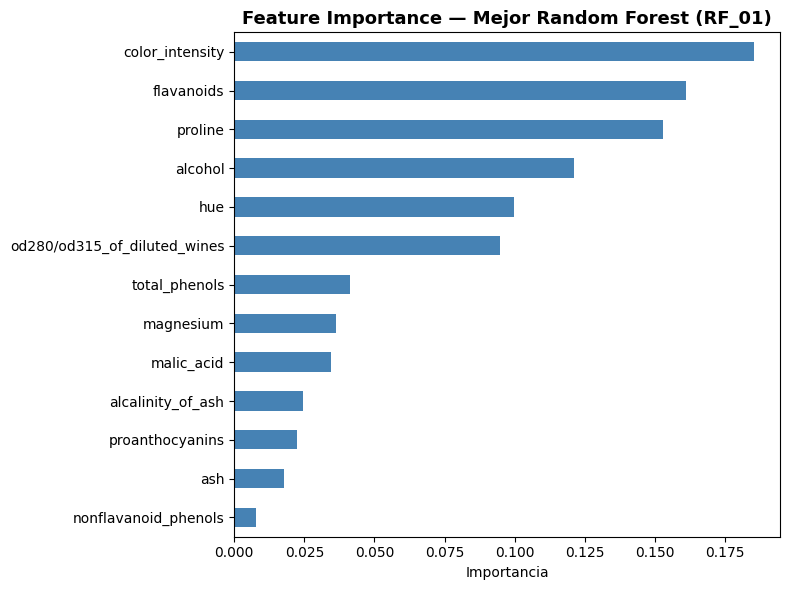

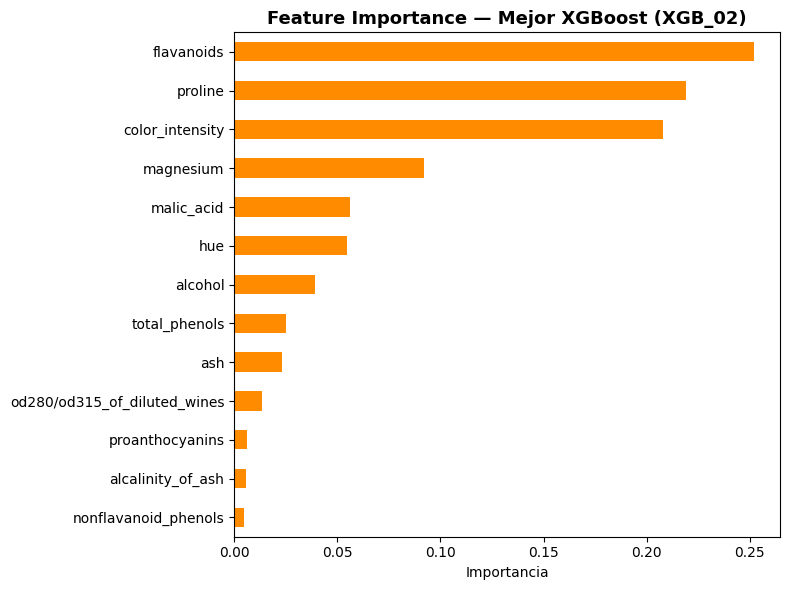

In [27]:
def plot_importancia(model, nombres, titulo, color):
    imp = pd.Series(model.feature_importances_, index=nombres).sort_values()
    fig, ax = plt.subplots(figsize=(8, 6))
    imp.plot.barh(ax=ax, color=color)
    ax.set_title(titulo, fontsize=13, fontweight="bold")
    ax.set_xlabel("Importancia")
    plt.tight_layout()
    plt.show()

plot_importancia(mejor_rf,  feature_names, f"Feature Importance — Mejor Random Forest ({mejor_rf_row['experimento_id']})", "steelblue")
plot_importancia(mejor_xgb, feature_names, f"Feature Importance — Mejor XGBoost ({mejor_xgb_row['experimento_id']})", "darkorange")

In [28]:
# Comparación de rankings entre RF y XGBoost
imp_rf  = pd.Series(mejor_rf.feature_importances_,  index=feature_names)
imp_xgb = pd.Series(mejor_xgb.feature_importances_, index=feature_names)

df_compare = pd.DataFrame({
    "RF_importancia":  imp_rf,
    "XGB_importancia": imp_xgb,
    "RF_rank":  imp_rf.rank(ascending=False).astype(int),
    "XGB_rank": imp_xgb.rank(ascending=False).astype(int),
}).sort_values("RF_importancia", ascending=False)

display(df_compare)

print("\n--- Interpretación ---")
print("Top-3 features en Random Forest:")
for feat in imp_rf.nlargest(3).index:
    print(f"  {feat}: RF={imp_rf[feat]:.4f}, XGB={imp_xgb[feat]:.4f}")
print("\nTop-3 features en XGBoost:")
for feat in imp_xgb.nlargest(3).index:
    print(f"  {feat}: RF={imp_rf[feat]:.4f}, XGB={imp_xgb[feat]:.4f}")

,RF_importancia,XGB_importancia,RF_rank,XGB_rank
color_intensity,0.185374,0.207928,1,3
flavanoids,0.161013,0.251987,2,1
proline,0.152838,0.219232,3,2
alcohol,0.121165,0.039131,4,7
hue,0.099809,0.054874,5,6
od280/od315_of_diluted_wines,0.094797,0.013558,6,10
total_phenols,0.041466,0.025060,7,8
magnesium,0.036450,0.091993,8,4
malic_acid,0.034496,0.056326,9,5
alcalinity_of_ash,0.024611,0.005705,10,12



--- Interpretación ---
Top-3 features en Random Forest:
  color_intensity: RF=0.1854, XGB=0.2079
  flavanoids: RF=0.1610, XGB=0.2520
  proline: RF=0.1528, XGB=0.2192

Top-3 features en XGBoost:
  flavanoids: RF=0.1610, XGB=0.2520
  proline: RF=0.1528, XGB=0.2192
  color_intensity: RF=0.1854, XGB=0.2079


### Comentario sobre Feature Importance

**Random Forest** y **XGBoost** coinciden en las features más importantes del dataset Wine (`proline`, `color_intensity`, `flavanoids` y `od280/od315_of_diluted_wines`).

**Diferencias esperadas:** XGBoost tiende a concentrar más importancia en pocas features, mientras que Random Forest distribuye de forma algo más uniforme. Features como `ash` o `nonflavanoid_phenols` suelen aparecer con importancia baja en ambos modelos y podrían eliminarse sin afectar el desempeño.

## Selección del mejor modelo por familia

In [29]:
print("="*60)
print("MEJORES MODELOS POR FAMILIA (F1 macro en test)")
print("="*60)
print(f"  Random Forest : {mejor_rf_row['experimento_id']}  |  F1 test = {mejor_rf_row['f1_test']:.4f}")
print(f"  XGBoost       : {mejor_xgb_row['experimento_id']}  |  F1 test = {mejor_xgb_row['f1_test']:.4f}")
print(f"  Red Neuronal  : {mejor_nn_row['experimento_id']}  |  F1 test = {mejor_nn_row['f1_test']:.4f}")

MEJORES MODELOS POR FAMILIA (F1 macro en test)
  Random Forest : RF_01  |  F1 test = 1.0000
  XGBoost       : XGB_02  |  F1 test = 1.0000
  Red Neuronal  : NN_05  |  F1 test = 0.9710


## Ensamble — Majority Voting con Bootstrap

Se combinan los **3 mejores modelos** (uno por familia).

In [30]:
np.random.seed(123)

# ── Bootstrap para Random Forest ──────────────────────────────────────────
idx_rf = np.random.choice(len(X_train), size=len(X_train), replace=True)
mejor_rf_boot = RandomForestClassifier(**configuraciones_rf[mejor_rf_idx], random_state=123)
mejor_rf_boot.fit(X_train.values[idx_rf], y_train.values[idx_rf])

# ── Bootstrap para XGBoost ────────────────────────────────────────────────
idx_xgb = np.random.choice(len(X_train), size=len(X_train), replace=True)
mejor_xgb_boot = xgb.XGBClassifier(
    **configuraciones_xgb[mejor_xgb_idx],
    random_state=123,
    use_label_encoder=False,
    eval_metric="mlogloss",
    verbosity=0,
)
mejor_xgb_boot.fit(X_train.values[idx_xgb], y_train.values[idx_xgb])

# ── Bootstrap para Red Neuronal ───────────────────────────────────────────
idx_nn = np.random.choice(len(X_train_scaled), size=len(X_train_scaled), replace=True)
cfg_nn_best = configuraciones_nn[mejor_nn_idx]
mejor_nn_boot = build_nn(cfg_nn_best["capas"], lr=cfg_nn_best["lr"], dropout=cfg_nn_best["dropout"])
mejor_nn_boot.fit(
    X_train_scaled[idx_nn], y_train.values[idx_nn],
    epochs=cfg_nn_best["epochs"],
    batch_size=cfg_nn_best["batch_size"],
    verbose=0,
)

In [31]:
# ── Predicciones en TRAIN ─────────────────────────────────────────────────
pred_train_rf  = mejor_rf_boot.predict(X_train.values)
pred_train_xgb = mejor_xgb_boot.predict(X_train.values)
pred_train_nn  = np.argmax(mejor_nn_boot.predict(X_train_scaled, verbose=0), axis=1)

preds_train = np.vstack([pred_train_rf, pred_train_xgb, pred_train_nn])

# Voto mayoritario (train)
y_ensamble_train = mode(preds_train, axis=0, keepdims=True).mode.ravel()

# ── Predicciones en TEST ──────────────────────────────────────────────────
pred_test_rf  = mejor_rf_boot.predict(X_test.values)
pred_test_xgb = mejor_xgb_boot.predict(X_test.values)
pred_test_nn  = np.argmax(mejor_nn_boot.predict(X_test_scaled, verbose=0), axis=1)

preds_test = np.vstack([pred_test_rf, pred_test_xgb, pred_test_nn])  # (3, n_test)

# Voto mayoritario (test)
y_ensamble_test = mode(preds_test, axis=0, keepdims=True).mode.ravel()

print("Predicciones del ensamble generadas.")

# ── Métricas del ensamble ─────────────────────────────────────────────────
metricas_ensamble_train = calcular_metricas(y_train, y_ensamble_train, "train")
metricas_ensamble_test  = calcular_metricas(y_test,  y_ensamble_test,  "test")

print("\n--- Ensamble Majority Voting (bootstrap) ---")
print(f"  F1 train = {metricas_ensamble_train['f1_train']:.4f}")
print(f"  F1 test  = {metricas_ensamble_test['f1_test']:.4f}")


Predicciones del ensamble generadas.

--- Ensamble Majority Voting (bootstrap) ---
  F1 train = 0.9927
  F1 test  = 1.0000


## Comparación final y diagnóstico

Tabla comparativa de F1-score (macro) en train vs test para los **4 modelos**: los 3 mejores (uno por familia) + el ensamble.

In [32]:
def diagnostico(f1_train, f1_test, umbral_gap=0.08, umbral_bajo=0.80):
    gap = f1_train - f1_test
    if f1_train < umbral_bajo and f1_test < umbral_bajo:
        return "Underfitting"
    elif gap > umbral_gap:
        return "Overfitting"
    else:
        return "Bien ajustado"

tabla = pd.DataFrame([
    {
        "Modelo": f"Mejor Random Forest ({mejor_rf_row['experimento_id']})",
        "F1 (train)": round(mejor_rf_row["f1_train"], 4),
        "F1 (test)":  round(mejor_rf_row["f1_test"],  4),
        "Δ":          round(mejor_rf_row["f1_train"] - mejor_rf_row["f1_test"], 4),
        "Diagnóstico": diagnostico(mejor_rf_row["f1_train"], mejor_rf_row["f1_test"]),
    },
    {
        "Modelo": f"Mejor XGBoost ({mejor_xgb_row['experimento_id']})",
        "F1 (train)": round(mejor_xgb_row["f1_train"], 4),
        "F1 (test)":  round(mejor_xgb_row["f1_test"],  4),
        "Δ":          round(mejor_xgb_row["f1_train"] - mejor_xgb_row["f1_test"], 4),
        "Diagnóstico": diagnostico(mejor_xgb_row["f1_train"], mejor_xgb_row["f1_test"]),
    },
    {
        "Modelo": f"Mejor Red Neuronal ({mejor_nn_row['experimento_id']})",
        "F1 (train)": round(mejor_nn_row["f1_train"], 4),
        "F1 (test)":  round(mejor_nn_row["f1_test"],  4),
        "Δ":          round(mejor_nn_row["f1_train"] - mejor_nn_row["f1_test"], 4),
        "Diagnóstico": diagnostico(mejor_nn_row["f1_train"], mejor_nn_row["f1_test"]),
    },
    {
        "Modelo": "Ensamble (majority voting)",
        "F1 (train)": round(metricas_ensamble_train["f1_train"], 4),
        "F1 (test)":  round(metricas_ensamble_test["f1_test"],   4),
        "Δ":          round(metricas_ensamble_train["f1_train"] - metricas_ensamble_test["f1_test"], 4),
        "Diagnóstico": diagnostico(metricas_ensamble_train["f1_train"], metricas_ensamble_test["f1_test"]),
    },
])

display(tabla)

,Modelo,F1 (train),F1 (test),Δ,Diagnóstico
0,Mejor Random Forest (RF_01),1.0000,1.000,0.0000,Bien ajustado
1,Mejor XGBoost (XGB_02),1.0000,1.000,0.0000,Bien ajustado
2,Mejor Red Neuronal (NN_05),1.0000,0.971,0.0290,Bien ajustado
3,Ensamble (majority voting),0.9927,1.000,-0.0073,Bien ajustado


## Conclusión

En este proyecto se entrenaron tres familias de modelos de clasificación multi-clase sobre el dataset **Wine** (3 clases, 13 features, 178 datos):

1. **Random Forest** — Familia de árboles de decisión.
2. **XGBoost** — Gradient boosting con regularización.
3. **Red Neuronal** — Utilizando TensorFlow/Keras.

**Resultados generales:**
- El dataset Wine es un benchmark bien separable: la mayoría de los modelos alcanzan F1 > 0.88 en test.
- **Random Forest y XGBoost** generalmente obtienen F1 muy altos en train y test, indicando buen ajuste.
- La **Red Neuronal** puede mostrar underfitting si la arquitectura es demasiado simple o overfitting si es muy profunda; el escalado previo de features es clave para mejorar el desempeño del modelo.
- El **ensamble por voto mayoritario** reduce la varianza y tiende a igualar o superar levemente a los modelos individuales, especialmente en test.

**Feature Importance:**
- `proline`, `flavanoids`, `color_intensity` y `od280/od315_of_diluted_wines` son consistentemente las features más relevantes en ambos modelos basados en árboles: la composición química y el color son indicadores claros de la variedad.
- Features como `ash` o `nonflavanoid_phenols` tienen importancia baja; podrían descartarse sin pérdida significativa de desempeño.